# Section 16: Autoencoders

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import sys
import copy

## Denoising MNIST

In [2]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

labels = data[:, 0]
data = data[:, 1:]
data_norm = data / np.max(data)
data_t = torch.tensor(data_norm).float()

In [3]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.encoder1 = nn.Linear(784, 250)
            self.encoder2 = nn.Linear(250, 50)
            self.decoder1 = nn.Linear(50, 250)
            self.decoder2 = nn.Linear(250, 784)
            
        def forward(self, x):
            x = F.relu(self.encoder1(x))
            x = F.relu(self.encoder2(x))
            x = F.relu(self.decoder1(x))
            
            return torch.sigmoid(self.decoder2(x))
    
    ae_net_local = AeNet()
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)
    
    return ae_net_local, loss_function_local, optimizer_local

In [4]:
ae_net, loss_function, optimizer = create_model()

X = data_t[:5, :]
y_pred = ae_net(X)

print(X.shape)
print(y_pred.shape)

torch.Size([5, 784])
torch.Size([5, 784])


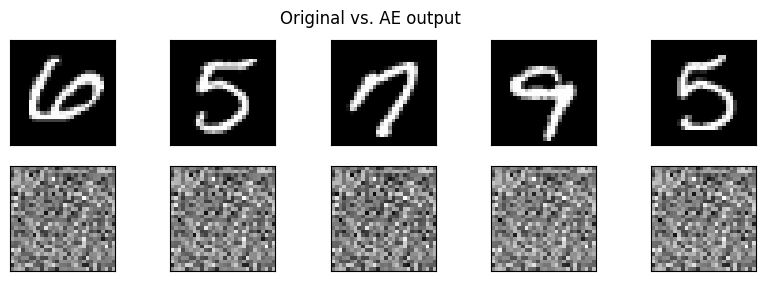

In [5]:
_, ax = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(y_pred[i, :].view(28, 28).detach(), cmap='gray')
    
    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    
plt.suptitle("Original vs. AE output")
plt.show()

In [6]:
def train_model():
    epochs_nr = 10000
    ae_net_local, loss_function_local, optimizer_local = create_model()
    losses_local = torch.zeros(epochs_nr)
    
    for epoch in range(epochs_nr):
        random_index = np.random.choice(data_t.shape[0], size=32)
        X_local = data_t[random_index, :]
        
        y_pred_local = ae_net_local(X_local)
        loss_local = loss_function_local(y_pred_local, X_local)
        
        optimizer_local.zero_grad()
        loss_local.backward()
        optimizer_local.step()
        
        losses_local[epoch] = loss_local.item()
        
    return losses_local, ae_net_local

In [7]:
losses, ae_net = train_model()

print(f"Final loss: {losses[-1]:.4f}")

Final loss: 0.0071


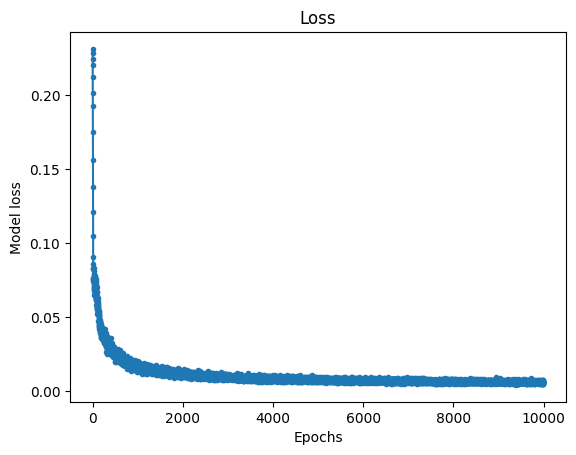

In [8]:
plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel("Model loss")
plt.title('Loss')
plt.show()

In [9]:
X = data_t[:5, :]

y_pred = ae_net(X)

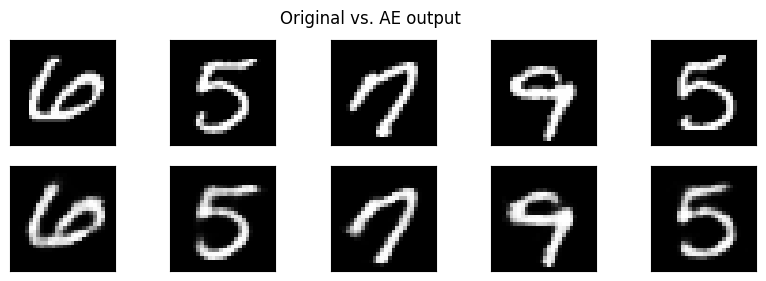

In [10]:
_, ax = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(y_pred[i, :].view(28, 28).detach(), cmap='gray')

    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    
plt.suptitle("Original vs. AE output")
plt.show()

In [11]:
X = data_t[:10, :]
X_noise = X + torch.rand_like(X) / 4
X_noise[X_noise > 1] = 1

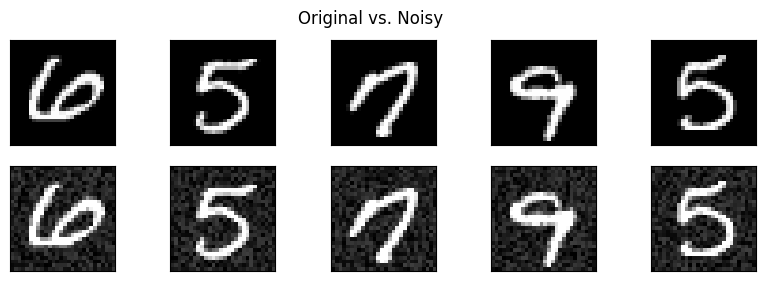

In [12]:
_, ax = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(X_noise[i, :].view(28, 28).detach(), cmap='gray')

    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    
plt.suptitle("Original vs. Noisy")
plt.show()

In [13]:
y_pred = ae_net(X_noise)

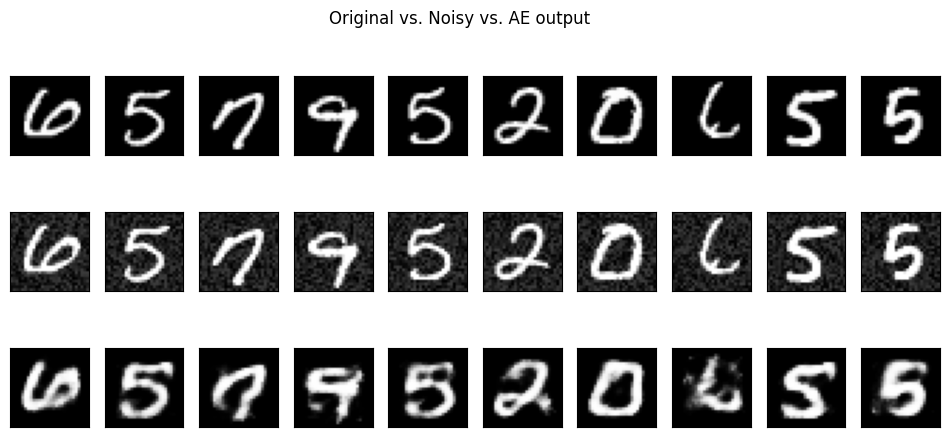

In [14]:
_, ax = plt.subplots(3, 10, figsize=(12, 5))

for i in range(10):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(X_noise[i, :].view(28, 28).detach(), cmap='gray')
    ax[2, i].imshow(y_pred[i, :].view(28, 28).detach(), cmap='gray')
    
    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    ax[2, i].set_xticks([]), ax[2, i].set_yticks([])
    
plt.suptitle("Original vs. Noisy vs. AE output")
plt.show()

## CodeChallenge: How many units?

In [15]:
def create_model(encoding_units_nr_param, bottleneck_units_nr_param):
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.encoder1 = nn.Linear(784, encoding_units_nr_param)
            self.encoder2 = nn.Linear(encoding_units_nr_param, bottleneck_units_nr_param)
            self.decoder1 = nn.Linear(bottleneck_units_nr_param, encoding_units_nr_param)
            self.decoder2 = nn.Linear(encoding_units_nr_param, 784)
            
        def forward(self, x):
            x = F.relu(self.encoder1(x))
            x = F.relu(self.encoder2(x))
            x = F.relu(self.decoder1(x))
            
            return torch.sigmoid(self.decoder2(x))
    
    ae_net_local = AeNet()
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)
    
    return ae_net_local, loss_function_local, optimizer_local

In [16]:
def train_model(encoding_units_nr_param, bottleneck_units_nr_param):
    epochs_nr = 3
    ae_net_local, loss_function_local, optimizer_local = create_model(encoding_units_nr_param, bottleneck_units_nr_param)
    losses_local = []
    
    for epoch in range(epochs_nr):
        batch_losses_local = []
        
        for X_local in data_t_batches:
            y_pred_local = ae_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)
            
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses_local.append(loss_local.item())
            
        losses_local.append(np.mean(batch_losses_local))
        
    return np.mean(losses_local[-3:])

In [17]:
encoding_units_nrs = np.int64(np.round(np.linspace(10, 500, 12)))
bottleneck_units_nrs = np.int64(np.round(np.linspace(5, 100, 8)))
data_t_batches = torch.split(data_t, 32)

In [18]:
final_losses = np.zeros((len(encoding_units_nrs), len(bottleneck_units_nrs)))
total_iterations = len(encoding_units_nrs) * len(bottleneck_units_nrs)
iteration_counter = 1

for e_index, encoding_units_nr in enumerate(encoding_units_nrs):
    for b_index, bottleneck_units_nr in enumerate(bottleneck_units_nrs):
        final_losses[e_index, b_index] = train_model(encoding_units_nr, bottleneck_units_nr)
        message = "\rFinished experiment {}/{}".format(iteration_counter, total_iterations)
        
        sys.stdout.write(message)
        sys.stdout.flush()
        
        iteration_counter += 1

Finished experiment 96/96

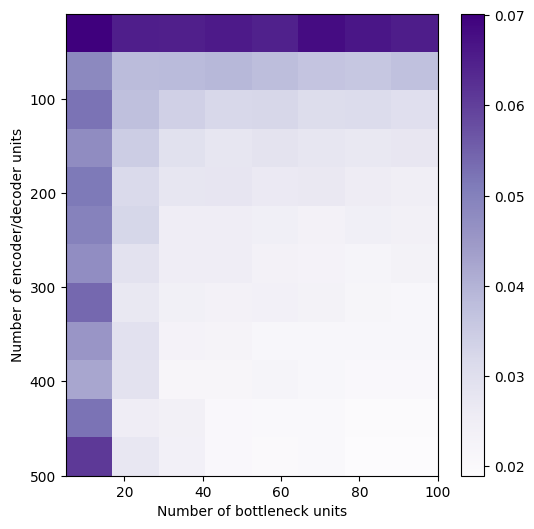

In [19]:
plt.figure(figsize=(6, 6))
plt.imshow(final_losses, aspect='auto', cmap='Purples', extent=[bottleneck_units_nrs[0], bottleneck_units_nrs[-1], encoding_units_nrs[-1], encoding_units_nrs[0]])
plt.ylabel("Number of encoder/decoder units")
plt.xlabel("Number of bottleneck units")
plt.colorbar()
plt.show()

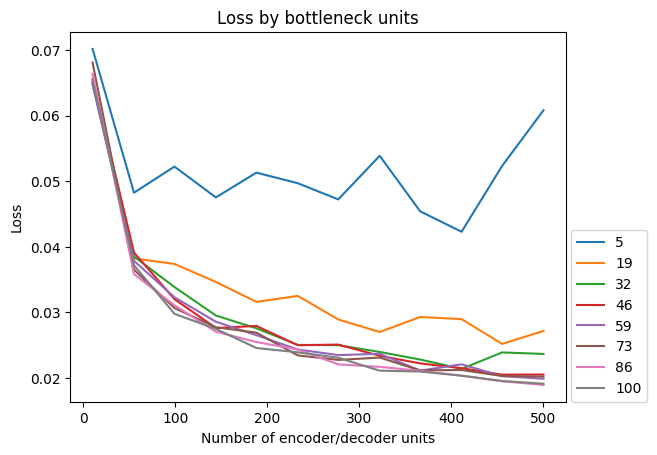

In [20]:
plt.plot(encoding_units_nrs, final_losses)
plt.legend(bottleneck_units_nrs, loc=(1.01, 0))
plt.xlabel("Number of encoder/decoder units")
plt.ylabel('Loss')
plt.title("Loss by bottleneck units")
plt.show()

## AEs for occlusion

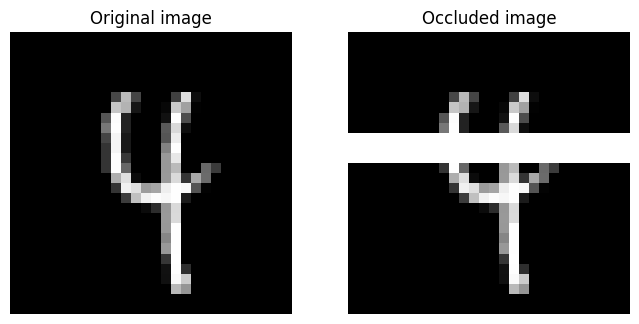

In [21]:
img = data_t[12345, :].view(28,28)
occluded_img = copy.deepcopy(img)
occluded_img[10:13, :] = 1

_, ax = plt.subplots(1, 2, figsize=(8, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original image")
ax[0].axis('off')

ax[1].imshow(occluded_img, cmap='gray')
ax[1].set_title("Occluded image")
ax[1].axis('off')

plt.show()

In [22]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.encoder1 = nn.Linear(784, 128)
            self.encoder2 = nn.Linear(128, 50)
            self.decoder1 = nn.Linear(50, 128)
            self.decoder2 = nn.Linear(128, 784)
            
        def forward(self, x):
            x = F.relu(self.encoder1(x))
            x = F.relu(self.encoder2(x))
            x = F.relu(self.decoder1(x))
            
            return torch.sigmoid(self.decoder2(x))
    
    ae_net_local = AeNet()
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)
    
    return ae_net_local, loss_function_local, optimizer_local

In [23]:
def train_model():
    epochs_nr = 5
    ae_net_local, loss_function_local, optimizer_local = create_model()
    losses_local = []
    
    for epoch in range(epochs_nr):
        batch_losses_local = []
        
        for X_local in data_t_batches:
            y_pred_local = ae_net_local(X_local)
            loss_local = loss_function_local(y_pred_local, X_local)
            
            optimizer_local.zero_grad()
            loss_local.backward()
            optimizer_local.step()
            
            batch_losses_local.append(loss_local.item())
            
        losses_local.append(np.mean(batch_losses_local))
        
    return losses_local, ae_net_local

In [24]:
losses, ae_net = train_model()

print(f"Final loss: {losses[-1]:.4f}")

Final loss: 0.0130


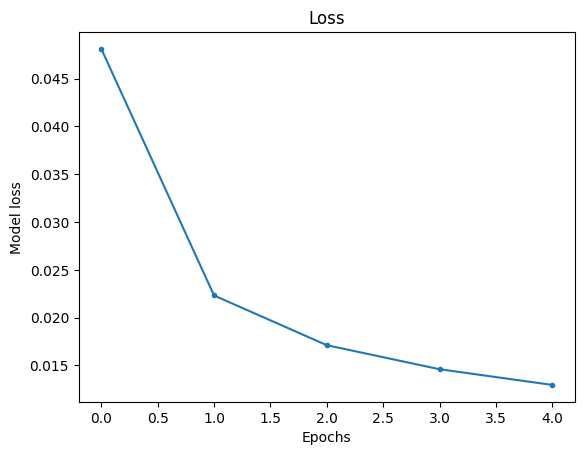

In [25]:
plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel("Model loss")
plt.title('Loss')
plt.show()

In [26]:
X = copy.deepcopy(data_t[:10, :])

for i in range(X.shape[0]):
    img = X[i, :].view(28, 28)
    start_loc = np.random.choice(range(10, 21))
    
    if i % 2 == 0:
        img[start_loc:start_loc + 1, :] = 1
    else:
        img[:, start_loc:start_loc + 1] = 1
        
deoccluded_imgs = ae_net(X)

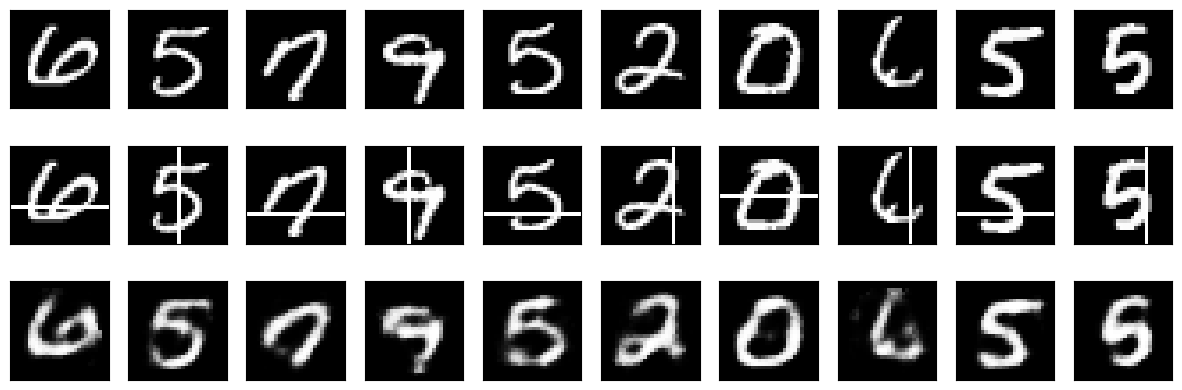

In [27]:
_, ax = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):
    ax[0, i].imshow(data_t[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[2, i].imshow(deoccluded_imgs[i, :].view(28, 28).detach(), cmap='gray')
    
    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    ax[2, i].set_xticks([]), ax[2, i].set_yticks([])
    
plt.show()

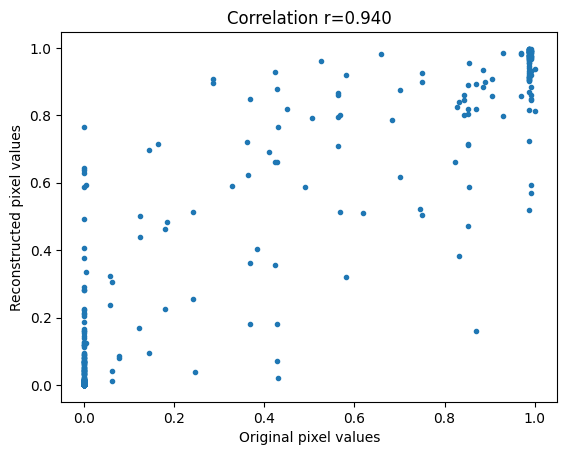

In [28]:
in_out_corr = np.corrcoef(data_t[9, :].detach(), deoccluded_imgs[9, :].detach())

plt.plot(data_t[9, :].detach(), deoccluded_imgs[9, :].detach(), '.')
plt.xlabel("Original pixel values")
plt.ylabel("Reconstructed pixel values")
plt.title(f"Correlation r={in_out_corr[0, 1]:.3f}")
plt.show()

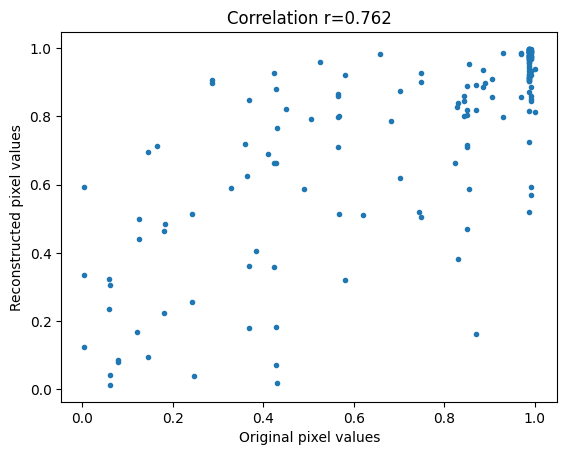

In [29]:
original_imgs = data_t[9, :].detach()
reconstructed_imgs = deoccluded_imgs[9, :].detach()

tolerance = 1e-4
non_zero_pixels = (original_imgs > tolerance) & (reconstructed_imgs > tolerance)

in_out_corr = np.corrcoef(original_imgs[non_zero_pixels], reconstructed_imgs[non_zero_pixels])

plt.plot(original_imgs[non_zero_pixels], reconstructed_imgs[non_zero_pixels], '.')
plt.xlabel("Original pixel values")
plt.ylabel("Reconstructed pixel values")
plt.title(f"Correlation r={in_out_corr[0, 1]:.3f}")
plt.show()

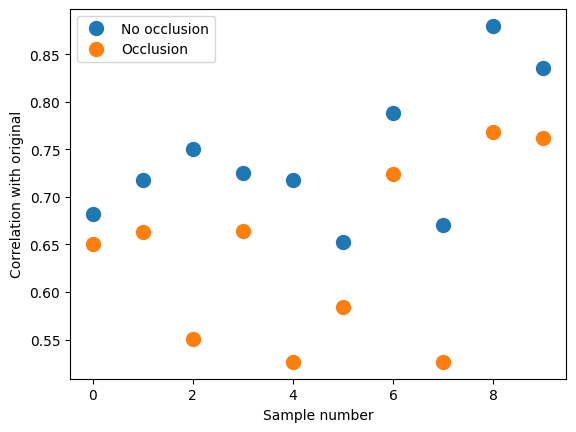

In [30]:
no_occlusion_imgs = ae_net(data_t[:10, :])
correlations = np.zeros((10, 2))

for i in range(deoccluded_imgs.shape[0]):
    non_zero_pixels = (data_t[i, :] > tolerance) & (deoccluded_imgs[i, :] > tolerance) & (no_occlusion_imgs[i, :] > tolerance)
    correlations[i, 0] = np.corrcoef(data_t[i, non_zero_pixels].detach(), no_occlusion_imgs[i, non_zero_pixels].detach())[0, 1]
    correlations[i, 1] = np.corrcoef(data_t[i, non_zero_pixels].detach(), deoccluded_imgs[i, non_zero_pixels].detach())[0, 1]
    
plt.plot(correlations, 'o', markersize=10)
plt.legend(["No occlusion", 'Occlusion'])
plt.xlabel("Sample number")
plt.ylabel("Correlation with original")
plt.show()

## The latent code of MNIST

In [31]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.encoder1 = nn.Linear(784, 150)
            self.encoder2 = nn.Linear(150, 15)
            self.decoder1 = nn.Linear(15, 150)
            self.decoder2 = nn.Linear(150, 784)
            
        def forward(self, x):
            x = F.relu(self.encoder1(x))
            latent_local = F.relu(self.encoder2(x))
            x = F.relu(self.decoder1(latent_local))
            
            return torch.sigmoid(self.decoder2(x)), latent_local
    
    ae_net_local = AeNet()
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)
    
    return ae_net_local, loss_function_local, optimizer_local

In [32]:
ae_net, loss_function, optimizer = create_model()

X = data_t[:5, :]
y_pred = ae_net(X)

print(f"Input shape: {X.shape}")
print(type(y_pred), len(y_pred))
print(f"Shape of model output: {y_pred[0].shape}")
print(f"Shape of encoding layer output: {y_pred[1].shape}")

Input shape: torch.Size([5, 784])
<class 'tuple'> 2
Shape of model output: torch.Size([5, 784])
Shape of encoding layer output: torch.Size([5, 15])


In [33]:
def train_model():
    epochs_nr = 10000
    ae_net_local, loss_function_local, optimizer_local = create_model()
    losses_local = torch.zeros(epochs_nr)
    
    for epoch in range(epochs_nr):
        random_index = np.random.choice(data_t.shape[0], size=32)
        X_local = data_t[random_index, :]
        
        y_pred_local = ae_net_local(X_local)[0]
        loss_local = loss_function_local(y_pred_local, X_local)
        
        optimizer_local.zero_grad()
        loss_local.backward()
        optimizer_local.step()
        
        losses_local[epoch] = loss_local.item()
        
    return losses_local, ae_net_local

In [34]:
losses, ae_net = train_model()

print(f"Final loss: {losses[-1]:.4f}")

Final loss: 0.0204


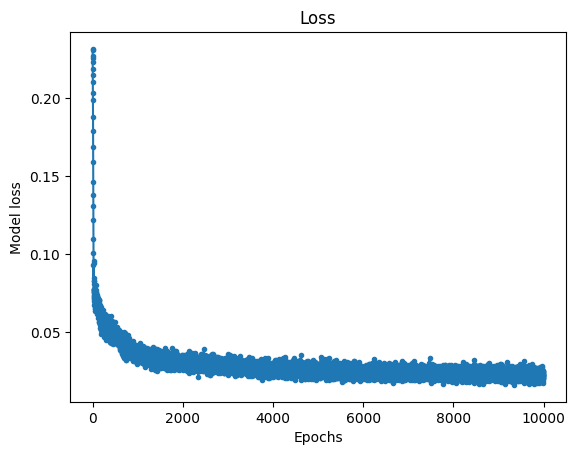

In [35]:
plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel("Model loss")
plt.title('Loss')
plt.show()

In [36]:
y_pred, latent = ae_net(data_t)

print(y_pred.shape)
print(latent.shape)

torch.Size([20000, 784])
torch.Size([20000, 15])


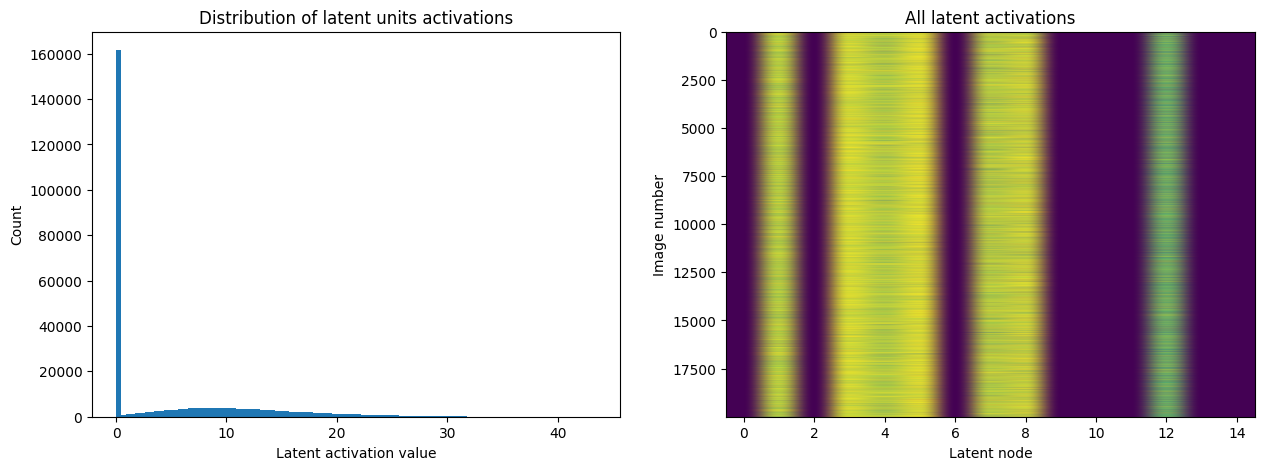

In [37]:
_, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(latent.flatten().detach(), 100)
ax[0].set_xlabel("Latent activation value")
ax[0].set_ylabel('Count')
ax[0].set_title("Distribution of latent units activations")

ax[1].imshow(latent.detach(), aspect='auto', vmin=0, vmax=10)
ax[1].set_xlabel("Latent node")
ax[1].set_ylabel("Image number")
ax[1].set_title("All latent activations")

plt.show()

In [38]:
source_code = np.zeros((latent.shape[1], 10))

for label in range(10):
    digit_indexes = np.where(labels == label)[0]
    source_code[:, label] = torch.mean(latent[digit_indexes, :], dim=0).detach().cpu().numpy()

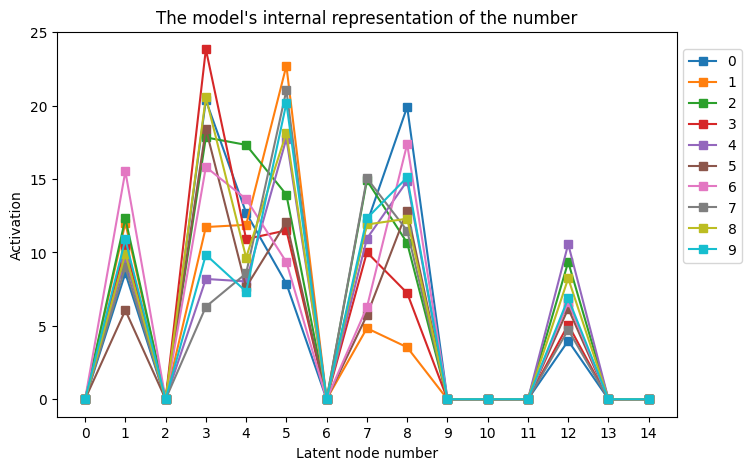

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(source_code, 's-')
plt.legend(range(10), loc=(1.01, .4))
plt.xticks(range(15))
plt.xlabel("Latent node number")
plt.ylabel('Activation')
plt.title("The model's internal representation of the number")
plt.show()

In [40]:
pca_data = PCA(n_components=15).fit(data)
pca_latent = PCA().fit(latent.detach())

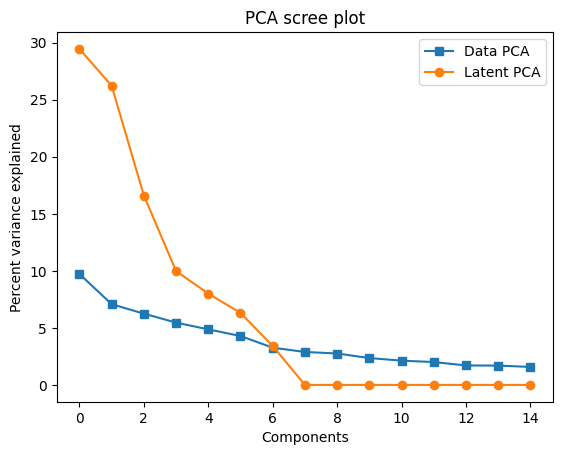

In [41]:
plt.plot(100 * pca_data.explained_variance_ratio_, 's-', label="Data PCA")
plt.plot(100 * pca_latent.explained_variance_ratio_, 'o-', label="Latent PCA")
plt.xlabel('Components')
plt.ylabel("Percent variance explained")
plt.title("PCA scree plot")
plt.legend()
plt.show()

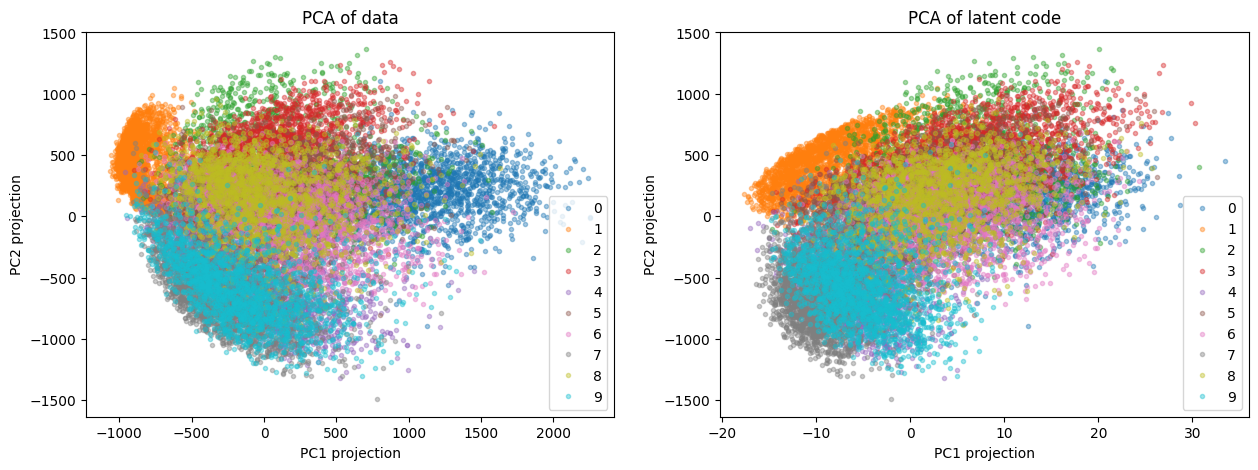

In [42]:
scores_data = pca_data.fit_transform(data)
scores_latent = pca_latent.fit_transform(latent.detach())

_, ax = plt.subplots(1, 2, figsize=(15, 5))

for label in range(10):
    ax[0].plot(scores_data[labels == label, 0], scores_data[labels == label, 1], 'o', markersize=3, alpha=.4)
    ax[1].plot(scores_latent[labels == label, 0], scores_data[labels == label, 1], 'o', markersize=3, alpha=.4)
    
for i in range(2):
    ax[i].set_xlabel("PC1 projection")
    ax[i].set_ylabel("PC2 projection")
    ax[i].legend(range(10))
    
ax[0].set_title("PCA of data")
ax[1].set_title("PCA of latent code")

plt.show()

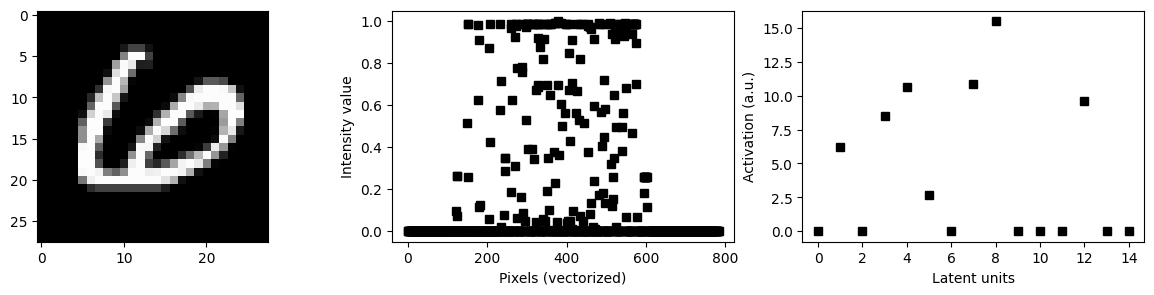

In [43]:
_, ax = plt.subplots(1, 3, figsize=(15, 3))

ax[0].imshow(data_t[0, :].view(28, 28), cmap='gray')

ax[1].plot(data_t[0, :], 'ks')
ax[1].set_xlabel("Pixels (vectorized)")
ax[1].set_ylabel("Intensity value")

ax[2].plot(latent[0, :].detach(), 'ks')
ax[2].set_xlabel("Latent units")
ax[2].set_ylabel("Activation (a.u.)")

plt.show()

## Autoencoder with tied weights

In [44]:
X = torch.rand(10, 50)
weights_1 = nn.Parameter(torch.randn(128, 50))

print(weights_1)
print()
print(weights_1.shape)
print(weights_1.t().shape)
print()

y = X @ weights_1.t()

print(y.shape)

Parameter containing:
tensor([[ 2.0744, -1.0098,  0.7860,  ..., -0.1881,  0.4794, -0.0175],
        [ 1.2594, -0.3060, -0.2180,  ..., -1.1622,  1.0670, -0.0125],
        [-0.1245, -0.7504, -1.3834,  ...,  0.5332,  0.2910, -0.2698],
        ...,
        [-0.0881,  0.3095,  2.1294,  ...,  1.3308,  0.9449,  0.3077],
        [ 0.2567, -1.3568, -0.3483,  ..., -0.4422, -0.8219,  2.3525],
        [-0.0527, -0.3377, -0.3162,  ..., -0.1889, -0.3390,  0.8891]],
       requires_grad=True)

torch.Size([128, 50])
torch.Size([50, 128])

torch.Size([10, 128])


In [45]:
weights_2 = nn.Linear(128, 50)

print(weights_2)
print()
print(weights_2.weight.shape)
print(weights_2.weight.t().shape)
print()

y = X @ weights_2.weight

print(y.shape)

Linear(in_features=128, out_features=50, bias=True)

torch.Size([50, 128])
torch.Size([128, 50])

torch.Size([10, 128])


In [46]:
def create_model():
    class AeNet(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.encoder1 = nn.Linear(784, 128)
            self.encoder2_decoder1 = nn.Parameter(torch.randn(50, 128))
            self.decoder2 = nn.Linear(128, 784)
            
        def forward(self, x):
            x = F.relu(self.encoder1(x))
            x = F.relu(x @ self.encoder2_decoder1.t())
            x = F.relu(x @ self.encoder2_decoder1)
            
            return torch.sigmoid(self.decoder2(x))
    
    ae_net_local = AeNet()
    loss_function_local = nn.MSELoss()
    optimizer_local = torch.optim.Adam(ae_net_local.parameters(), lr=.001)
    
    return ae_net_local, loss_function_local, optimizer_local

In [47]:
ae_net, loss_function, optimizer = create_model()

X = data_t[:5, :]
y_pred = ae_net(X)

print(X.shape)
print(y_pred.shape)

torch.Size([5, 784])
torch.Size([5, 784])


In [48]:
def train_model():
    epochs_nr = 10000
    ae_net_local, loss_function_local, optimizer_local = create_model()
    losses_local = torch.zeros(epochs_nr)
    
    for epoch in range(epochs_nr):
        random_index = np.random.choice(data_t.shape[0], size=32)
        X_local = data_t[random_index, :]
        
        y_pred_local = ae_net_local(X_local)
        loss_local = loss_function_local(y_pred_local, X_local)
        
        optimizer_local.zero_grad()
        loss_local.backward()
        optimizer_local.step()
        
        losses_local[epoch] = loss_local.item()
        
    return losses_local, ae_net_local

In [49]:
losses, ae_net = train_model()

print(f"Final loss: {losses[-1]:.4f}")

Final loss: 0.0120


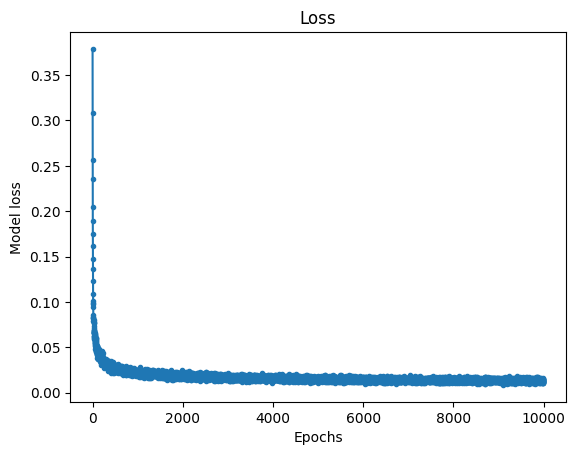

In [50]:
plt.plot(losses, '.-')
plt.xlabel('Epochs')
plt.ylabel("Model loss")
plt.title('Loss')
plt.show()

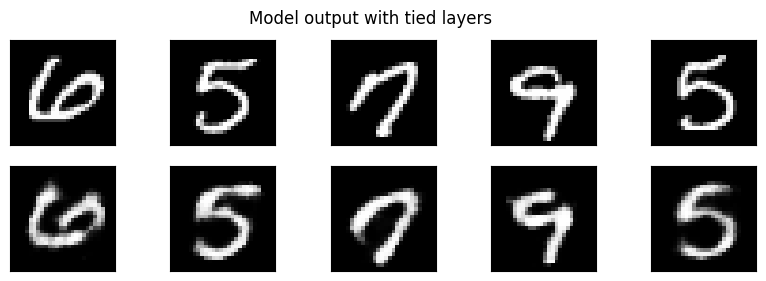

In [51]:
X = data_t[:5, :]
y_pred = ae_net(X)

_, ax = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(y_pred[i, :].view(28, 28).detach(), cmap='gray')

    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    
plt.suptitle("Model output with tied layers")
plt.show()

In [52]:
X = data_t[:10, :]
X_noise = X + torch.rand_like(X) / 4
X_noise[X_noise > 1] = 1

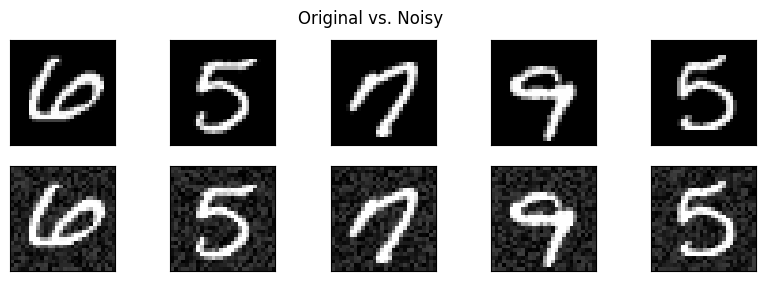

In [53]:
_, ax = plt.subplots(2, 5, figsize=(10, 3))

for i in range(5):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(X_noise[i, :].view(28, 28).detach(), cmap='gray')

    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    
plt.suptitle("Original vs. Noisy")
plt.show()

In [54]:
y_pred = ae_net(X_noise)

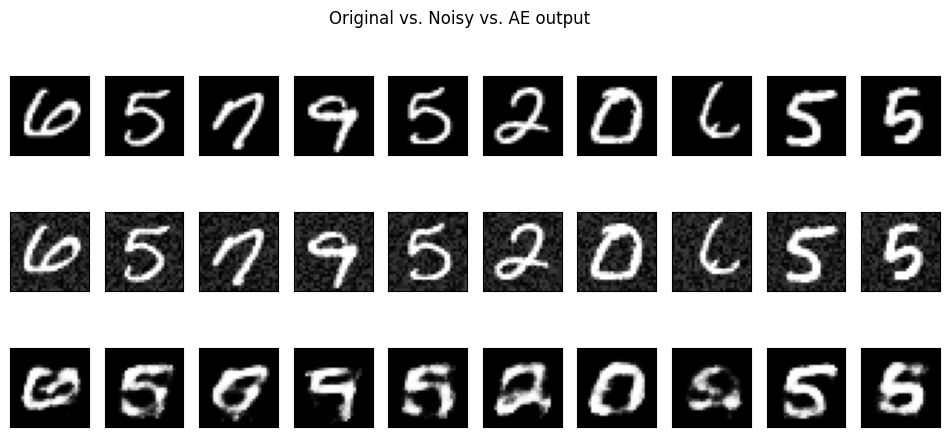

In [55]:
_, ax = plt.subplots(3, 10, figsize=(12, 5))

for i in range(10):
    ax[0, i].imshow(X[i, :].view(28, 28).detach(), cmap='gray')
    ax[1, i].imshow(X_noise[i, :].view(28, 28).detach(), cmap='gray')
    ax[2, i].imshow(y_pred[i, :].view(28, 28).detach(), cmap='gray')

    ax[0, i].set_xticks([]), ax[0, i].set_yticks([])
    ax[1, i].set_xticks([]), ax[1, i].set_yticks([])
    ax[2, i].set_xticks([]), ax[2, i].set_yticks([])

plt.suptitle("Original vs. Noisy vs. AE output")
plt.show()